# AICE Associate 예상 문제 4회: 광고 캠페인 수익률 예측

**과제: 디지털 광고 캠페인 수익률(ROI) 예측 AI 모델 개발**

**도메인: 마케팅**

**배경:**
디지털 마케팅에서 광고비 대비 수익률(ROI)을 정확히 예측하는 것은 예산 분배와 캠페인 전략 수립의 핵심입니다. 'AICE 마케팅 솔루션'은 다양한 채널에서 집행된 과거 광고 캠페인 데이터를 분석하여, 특정 조건(광고 채널, 비용, 기간, 타겟 등)에서 예상되는 수익률을 예측하는 AI 모델을 개발하고자 합니다. 이 모델은 마케터들이 데이터를 기반으로 더 효율적인 광고 캠페인을 기획하고 예산을 최적화하는 데 도움을 줄 것입니다.

**데이터셋 설명 (파일명: `4_ad_campaign_roi.csv`)**

* `channel`: 광고가 집행된 채널 (Search, TV, Radio, Social)
* `cost_millions`: 캠페인에 사용된 총 광고비 (단위: 백만원)
* `duration_days`: 캠페인 진행 기간 (일)
* `target_age`: 주요 타겟 연령대 (10s, 20-30s, 40-50s, All)
* `impressions`: 광고 노출 수
* `clicks`: 광고 클릭 수
* `conversions`: 구매 또는 회원가입 등 목표 행동으로 전환된 수
* **`roi_percentage`**: **예측 목표(Target)**, 광고비 대비 수익률 (%)

--- 
#### **사전 실행 코드**
> 모든 문제를 풀기 전에 아래 코드를 실행해주세요.

In [1]:
# 데이터 분석 및 시각화에 필요한 기본 라이브러리들을 불러옵니다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn 라이브러리에서 필요한 모듈들을 불러옵니다.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


--- 
#### **문제 1.**

TensorFlow는 구글에서 개발한 딥러닝 및 머신러닝을 위한 강력한 오픈소스 라이브러리입니다. `tensorflow` 라이브러리를 별칭 `tf`로 임포트하는 코드를 작성하세요.

In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 1**


* **상세 해설:**
    `import 라이브러리 as 별칭` 구문을 사용하여 `tensorflow` 라이브러리를 `tf`라는 표준 별칭으로 불러옵니다. TensorFlow는 딥러닝 모델을 구축하고 학습시키는 데 사용되는 핵심 라이브러리입니다.

In [2]:
import tensorflow as tf

--- 
#### **문제 2.**

AI 모델링을 위해 분석할 데이터를 준비하고 기본적인 정보를 파악하려고 합니다. 아래 가이드에 따라 코드를 작성하세요.

1.  Pandas의 `read_csv` 함수를 사용하여 `4_ad_campaign_roi.csv` 파일을 읽어 데이터프레임 변수 `ad_df`에 할당하세요.
2.  `head()` 함수를 사용하여 `ad_df`의 상위 5개 행을 출력하여 데이터를 확인하세요.

In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 2**


* **상세 해설**
  
    `pandas`의 `read_csv()` 함수를 사용하여 지정된 파일명의 데이터를 읽어 `ad_df` 데이터프레임에 저장합니다. 그 후, `head()` 메소드를 사용하여 데이터의 첫 5행을 출력함으로써 데이터가 올바르게 로드되었는지, 컬럼명은 무엇인지 등을 빠르게 확인합니다.

In [3]:
# '4_ad_campaign_roi.csv' 파일을 읽어 ad_df 변수에 저장합니다.
ad_df = pd.read_csv('C:\\Users\\User\\Desktop\\2026 이패스 AI능력시험 AI Associate 실전모의고사 10_DATA\\2026 이패스 AI능력시험 AI Associate 실전모의고사 10_DATA\\4_ad_campaign_roi.csv')

# 데이터의 상위 5개 행을 출력하여 확인합니다.
ad_df.head()

,channel,cost_millions,duration_days,target_age,impressions,clicks,conversions,roi_percentage
0,검색광고,564.0,59.0,2030대,1051296.0,13865.0,1106.0,-77.92
1,TV,89.0,20.0,전체,111250.0,229.0,18.0,-106.58
2,라디오,62.0,76.0,2030대,153450.0,6102.0,174.0,-92.96
3,라디오,21.0,18.0,10대,23037.0,1007.0,12.0,-96.55
4,TV,971.0,90.0,4050대,1310850.0,62609.0,3036.0,-85.28


--- 
#### **문제 3.**

`광고비(cost_millions)`와 `수익률(roi_percentage)` 사이의 관계를 시각적으로 탐색하고자 합니다.  
`seaborn`의 `scatterplot`을 사용하여 두 변수 간의 관계를 시각화하세요.

* **x축**: `cost_millions`
* **y축**: `roi_percentage`
* **데이터**: `ad_df`
* **추가 옵션**: 점의 색상(`hue`)을 `channel` 기준으로 구분하여 표시

In [4]:
# 한글화를 위해 아래의 코드를 작성해 주세요.
import platform
from matplotlib import rc

if platform.system() == 'Darwin':  # macOS
    rc('font', family='AppleGothic')
else:  # Windows
    rc('font', family='Malgun Gothic')

plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 3**

* **상세 해설**
  
    `seaborn`의 `scatterplot`은 두 수치형 변수 간의 관계를 점으로 나타내는 산점도를 그립니다. `x`축에 `cost_millions`, `y`축에 `roi_percentage`를 설정하여 광고비와 수익률 간의 관계를 시각화합니다. 여기에 `hue='channel'` 옵션을 추가하면, 각 점의 색상이 광고 채널에 따라 다르게 표시되어, 채널별로 광고비-수익률 관계에 차이가 있는지 한눈에 파악할 수 있습니다.

<Axes: xlabel='cost_millions', ylabel='roi_percentage'>

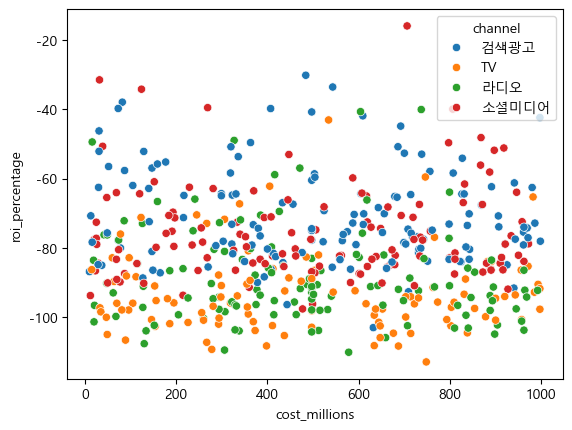

In [5]:
sns.scatterplot(data=ad_df, x='cost_millions', y='roi_percentage', hue='channel')

--- 
#### **문제 4.**

광고 `채널(channel)`에 따라 `수익률(roi_percentage)`의 분포가 어떻게 다른지 확인하려고 합니다.  
`seaborn`의 `boxplot`을 사용하여 채널별 수익률 분포를 시각화하고, 수익률의 중앙값이 가장 높은 채널을 `답안04` 변수에 문자열로 저장하세요.

* **x축**: `channel`
* **y축**: `roi_percentage`
* **데이터**: `ad_df`

In [ ]:
# 여기에 답안코드를 작성하세요.


# 그래프를 보고 수익률의 중앙값이 가장 높은 채널을 아래 변수에 저장하세요.
답안04 = # 예: 'TV'

#### **[해설 및 핵심 이론] 문제 4**


* **상세 해설**
   
    `boxplot`은 각 그룹(채널)의 데이터 분포를 상자 모양으로 요약하여 보여줍니다. 상자 안의 가로선은 중앙값(median)을 나타냅니다. 그래프를 그려보면 'Search' 채널의 상자 안 가로선이 다른 채널들보다 높은 위치에 있으므로, 중앙값이 가장 높다는 것을 알 수 있습니다.

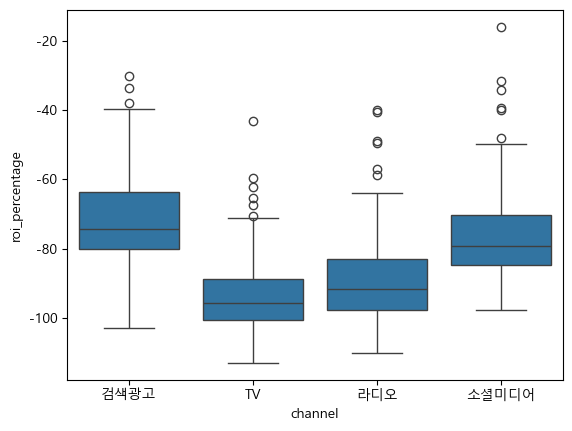

In [6]:
sns.boxplot(data=ad_df, x='channel', y='roi_percentage')

# 그래프를 통해 '검색광고'의 중앙값이 가장 높음을 알 수 있습니다.
답안04 = '검색광고'

--- 
#### **문제 5.**

`채널(channel)`과 `타겟연령대(target_age)`를 조합했을 때의 평균 `클릭수(clicks)`와 `전환수(conversions)`를 확인하고자 합니다.  
`groupby()`를 사용하여 데이터를 두 기준으로 그룹화하고, 두 지표의 평균을 계산하세요.

In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 5**


* **상세 해설**
  
    `groupby()`에 리스트 형태로 여러 컬럼(`['channel', 'target_age']`)을 전달하여 다중 그룹화를 수행합니다. 그 후 `['clicks', 'conversions']` 컬럼들을 선택하고 `.mean()`으로 평균을 계산하여, 채널과 타겟 연령대 조합에 따른 평균 클릭수와 전환수를 확인합니다.

In [7]:
# 'channel'과 'target_age'로 그룹화하여 평균 클릭수와 전환수를 계산합니다.
avg_metrics = ad_df.groupby(['channel', 'target_age'])[['clicks', 'conversions']].mean()
avg_metrics

clicks  conversions
channel target_age                           
TV      10대         19490.163622   891.508775
        2030대       30536.506721  1617.037579
        4050대       23593.051174  1138.007721
        전체          22613.200000   881.564570
검색광고    10대         31036.756819  1655.831070
        2030대       31869.008264  1502.430061
        4050대       26442.000000  1472.280374
        전체          22118.184072  1260.866667
라디오     10대         21372.138300  1355.200000
        2030대       22141.966415  1069.544574
        4050대       22608.329688  1543.260870
        전체          22377.281250  1085.812500
소셜미디어   10대         23496.846154  1438.091425
        2030대       26254.350000  1523.314541
        4050대       24430.833333  1265.933333
        전체          27572.661237  1739.483871

--- 
#### **문제 6.**

모델링을 위해 데이터의 결측치를 처리하고 데이터 타입을 변환하려고 합니다. 아래 가이드에 따라 전처리를 수행하고, 결과를 `ad_pre` 변수에 저장하세요.

1.  `ad_df` 데이터프레임을 복사하여 `ad_pre`를 생성합니다.
2.  `cost_millions`와 `duration_days` 컬럼의 결측치는 각 컬럼의 **중앙값(median)** 으로 채우세요.

In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 6**


* **상세 해설**
  
    `copy()`로 데이터프레임을 복사합니다. 결측치가 있는 수치형 컬럼들에 대해 각 컬럼의 중앙값(`.median()`)을 계산하고, `fillna()`로 결측치를 채웁니다. 중앙값은 평균값에 비해 이상치(outlier)의 영향을 덜 받기 때문에, 데이터에 극단적인 값이 있을 경우 더 안정적인 대치 방법이 될 수 있습니다.

In [8]:
# 원본 보존을 위해 데이터프레임을 복사합니다.
ad_pre = ad_df.copy()

# 결측치가 있는 수치형 컬럼 리스트
cols_to_fill = ['cost_millions', 'duration_days']

# 반복문을 사용하여 각 컬럼의 결측치를 중앙값으로 채우기
for col in cols_to_fill:
    median_val = ad_pre[col].median()
    ad_pre[col].fillna(median_val, inplace=True)

# 전처리 결과 확인
ad_pre.isnull().sum()

C:\Users\User\AppData\Local\Temp\ipykernel_32612\615563019.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ad_pre[col].fillna(median_val, inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_32612\615563019.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

channel           0
cost_millions     0
duration_days     0
target_age        0
impressions       0
clicks            0
conversions       0
roi_percentage    0
dtype: int64

--- 
#### **문제 7.**

기존 변수를 조합하여 새로운 특성, `클릭률(CTR)`을 생성하려고 합니다.  
`클릭률`은 `클릭수 / 노출수`로 계산됩니다. `ad_pre` 데이터프레임에 `ctr`이라는 새로운 컬럼을 추가하고, 이 값을 계산하여 할당하세요.  
`np.where`을 이용하여 처리하세요.

* **주의**: `노출수(impressions)`가 0인 경우 0으로 나누는 에러가 발생할 수 있으므로, `노출수`가 0일 때는 `클릭률`도 0이 되도록 처리하세요.

In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 7**


* **상세 해설**
  
    피처 엔지니어링은 기존 변수를 가공하거나 조합하여 모델의 성능을 높일 수 있는 새로운 변수를 만드는 과정입니다. 클릭률(CTR)은 마케팅 분석에서 매우 중요한 지표입니다. `np.where()` 함수를 사용하여 조건부로 값을 할당합니다. `impressions`가 0일 때는 0을, 그렇지 않을 때는 `clicks / impressions` 계산 결과를 `ctr` 컬럼에 할당하여 0으로 나누는 에러를 방지합니다.

* **핵심 이론**
    * **피처 엔지니어링 (Feature Engineering)**: 모델의 예측력을 높이기 위해 데이터에 대한 이해를 바탕으로 새로운 특성(feature)을 만들어내는 과정입니다.
    * **`np.where(condition, value_if_true, value_if_false)`**: `condition`이 참일 경우 `value_if_true`를, 거짓일 경우 `value_if_false`를 반환하는 유용한 함수입니다.

In [9]:
# np.where를 사용하여 조건부로 CTR 계산
# impressions가 0이면 0, 아니면 clicks / impressions
ad_pre['ctr'] = np.where(ad_pre['impressions'] == 0, 0, ad_pre['clicks'] / ad_pre['impressions'])

# 생성된 컬럼 확인
ad_pre.head()

,channel,cost_millions,duration_days,target_age,impressions,clicks,conversions,roi_percentage,ctr
0,검색광고,564.0,59.0,2030대,1051296.0,13865.0,1106.0,-77.92,0.013188
1,TV,89.0,20.0,전체,111250.0,229.0,18.0,-106.58,0.002058
2,라디오,62.0,76.0,2030대,153450.0,6102.0,174.0,-92.96,0.039765
3,라디오,21.0,18.0,10대,23037.0,1007.0,12.0,-96.55,0.043712
4,TV,971.0,90.0,4050대,1310850.0,62609.0,3036.0,-85.28,0.047762


--- 
#### **문제 8.**

모델이 이해할 수 있도록 범주형 데이터를 원-핫 인코딩으로 변환하고, 훈련과 검증에 사용할 데이터셋을 분리하려고 합니다. 아래 순서에 따라 코드를 작성하세요.

1.  `pandas`의 `get_dummies()` 함수를 사용하여 `channel`과 `target_age` 컬럼을 원-핫 인코딩하고, 결과를 `ad_encoded` 변수에 저장하세요.
2.  `ad_encoded` 데이터셋에서 `roi_percentage` 컬럼을 label `y`로, 나머지 컬럼들을 feature `X`로 할당하세요.
3.  `train_test_split` 함수를 사용하여 훈련 데이터셋과 검증 데이터셋을 80:20 비율로 분리하세요. (`random_state=2024`)

In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 8**


* **상세 해설**
  
    순서가 없는 명목형 데이터인 `channel`과 `target_age` 컬럼은 `get_dummies()`를 사용하여 원-핫 인코딩을 수행합니다. 이렇게 모든 데이터가 숫자형으로 변환된 `ad_encoded` 데이터프레임을 기준으로, `drop()`을 사용하여 `roi_percentage` 컬럼을 제외한 나머지를 `X`로, `roi_percentage` 컬럼을 `y`로 분리합니다. 마지막으로 `train_test_split` 함수를 사용하여 데이터를 분리합니다.

In [10]:
# 1. 범주형 컬럼 원-핫 인코딩
ad_encoded = pd.get_dummies(ad_pre, columns=['channel', 'target_age'])

# 2. Feature(X)와 Label(y) 분리
X = ad_encoded.drop('roi_percentage', axis=1)
y = ad_encoded['roi_percentage']

# 3. 훈련 데이터와 검증 데이터로 분리
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=2024)

# 분리 결과 확인
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)

X_train shape: (400, 14)
X_valid shape: (100, 14)


--- 
#### **문제 9.**

수치형 데이터들의 단위를 맞춰주기 위해 데이터 스케일링을 진행합니다. 평균을 0, 표준편차를 1로 변환하는 `StandardScaler`를 사용하여 훈련 데이터와 검증 데이터의 Feature(`X_train`, `X_valid`)를 스케일링하는 코드를 작성하세요.

* 훈련 데이터에는 `fit_transform()`을, 검증 데이터에는 `transform()`을 적용하세요.
* 스케일링된 결과는 각각 `X_train_scaled`, `X_valid_scaled` 변수에 저장하세요.

In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 9**


* **상세 해설**
  
    `StandardScaler` 객체를 생성합니다. **훈련 데이터(`X_train`)에는 `fit_transform()`을 적용**하여 스케일링 규칙(평균, 표준편차)을 학습하고 변환하며, **검증 데이터(`X_valid`)에는 `transform()`만 적용**하여 데이터 누수를 방지합니다.

In [11]:
# StandardScaler 객체 생성
scaler = StandardScaler()

# 훈련 데이터에 fit_transform 적용
X_train_scaled = scaler.fit_transform(X_train)

# 검증 데이터에 transform 적용
X_valid_scaled = scaler.transform(X_valid)

--- 
#### **문제 10.**

가장 기본적인 회귀 모델인 `LinearRegression`을 사용하여 수익률 예측 모델을 학습시키려고 합니다. 아래 가이드에 따라 모델을 생성하고 학습시키는 코드를 작성하세요.

* `sklearn.linear_model`의 `LinearRegression` 함수 사용
* 모델 객체는 `model_lr` 변수에 저장하고, 스케일링된 훈련 데이터로 학습시키세요.

In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 10**

* **상세 해설:**
    `LinearRegression`은 각 특성(feature)에 가중치를 곱하여 예측값을 계산하는 가장 기본적인 선형 회귀 모델입니다. 모델의 구조가 단순하여 해석이 용이하고, 다른 복잡한 모델의 성능을 평가하기 위한 기준선(baseline) 모델로 자주 사용됩니다.

In [12]:
# LinearRegression 모델 객체 생성
model_lr = LinearRegression()

# 모델 학습
model_lr.fit(X_train_scaled, y_train)


LinearRegression()

--- 
#### **문제 11.**

이번에는 `RandomForestRegressor` 모델을 사용하여 학습을 진행하고, 모델이 어떤 특성을 중요하게 생각하는지 확인하려고 합니다. 아래 가이드에 따라 모델을 학습시키고, 가장 중요한 특성의 이름을 `답안11` 변수에 저장하세요.

* `sklearn.ensemble`의 `RandomForestRegressor` 함수 사용
* **하이퍼파라미터 설정**:
    * `n_estimators`: 100
    * `max_depth`: 7
    * `random_state`: 2024
* 모델 객체는 `model_rf` 변수에 저장하고 학습시키세요.
* 학습 후 `feature_importances_` 속성을 확인하여 가장 중요한 특성의 컬럼명을 `답안11`에 저장하세요.

In [ ]:
# 여기에 답안코드를 작성하세요.


# 가장 중요한 특성의 컬럼명을 아래 변수에 저장하세요.
답안11 = # 예: 'cost_millions'

#### **[해설 및 핵심 이론] 문제 11**

* **상세 해설**
  
    `RandomForestRegressor`는 여러 개의 의사결정나무를 만들어 그 예측 결과를 평균내는 앙상블 모델입니다. 학습 후 `.feature_importances_` 속성을 통해 어떤 특성이 수익률 예측에 중요한 영향을 미쳤는지 확인할 수 있습니다.

In [13]:
# RandomForestRegressor 모델 객체 생성
model_rf = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=2024)

# 모델 학습
model_rf.fit(X_train_scaled, y_train)

# 특성 중요도 확인
importances = model_rf.feature_importances_
feature_names = X.columns
most_important_idx = np.argmax(importances)
most_important_feature = feature_names[most_important_idx]

# 답안 변수에 저장
답안11 = most_important_feature

print(f"가장 중요한 특성: {답안11}")

가장 중요한 특성: conversions


--- 
#### **문제 12.**

앞서 학습한 두 머신러닝 모델(`model_lr`, `model_rf`)의 성능을 평가하려고 합니다.  
선형 회귀(Linear Regession)는 `lr_pred`, 랜덤 포레스트(Random Forest)는 `rf_pred` 변수로 지정하여 예측 값을 저장하세요.  
회귀 모델의 성능을 평가하는 대표적인 지표인 **MAE(Mean Absolute Error)** 와 **R² Score(결정계수)** 를 계산하는 코드를 작성하세요.

* 두 모델에 대해 각각 두 가지 평가지표를 모두 계산하고 출력하세요.

In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 12**


* **상세 해설**  
    `mean_absolute_error`와 `r2_score` 함수를 임포트합니다. 각 모델에 대해 예측값을 구하고, 평가 함수에 `(실제값, 예측값)` 순서로 인자를 넣어 성능 지표를 계산합니다. MAE는 오차의 절댓값 평균으로, 결과를 직관적으로 해석하기 좋습니다(예: "평균적으로 약 5%p 정도 수익률 오차가 난다").

In [14]:
# 1. LinearRegression 모델 성능 평가
lr_pred = model_lr.predict(X_valid_scaled)
lr_mae = mean_absolute_error(y_valid, lr_pred)
lr_r2 = r2_score(y_valid, lr_pred)

print("--- LinearRegression 성능 ---")
print(f"MAE: {lr_mae:.4f}")
print(f"R² Score: {lr_r2:.4f}\n")

# 2. RandomForestRegressor 모델 성능 평가
rf_pred = model_rf.predict(X_valid_scaled)
rf_mae = mean_absolute_error(y_valid, rf_pred)
rf_r2 = r2_score(y_valid, rf_pred)

print("--- RandomForestRegressor 성능 ---")
print(f"MAE: {rf_mae:.4f}")
print(f"R² Score: {rf_r2:.4f}")

--- LinearRegression 성능 ---
MAE: 5.8347
R² Score: 0.7723

--- RandomForestRegressor 성능 ---
MAE: 5.4970
R² Score: 0.7835


--- 
#### **문제 13.**

이번에는 딥러닝을 사용하여 수익률 예측 모델을 만들려고 합니다. 아래의 가이드에 따라 `tensorflow.keras`를 사용하여 회귀 모델을 구축하고 학습시키세요.

* `Sequential` 모델을 사용하세요.
* **모델 구조**:
    * **입력층**: `Dense` 레이어, 32개 노드, 활성화 함수 `relu`
    * **은닉층 1**: `Dense` 레이어, 16개 노드, 활성화 함수 `relu`
    * **출력층**: `Dense` 레이어, **1개 노드**
* **컴파일 설정**:
    * `optimizer`: `adam`
    * `loss`: `mean_absolute_error`
* **학습 설정**:
    * `epochs`: 50
    * `batch_size`: 16
    * `validation_data`로 `X_valid_scaled`, `y_valid`를 사용하여 검증 손실도 함께 확인하세요.
* 학습 과정은 `history` 변수에 저장하세요.

In [15]:
# 아래의 코드를 실행해 주세요.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 13**


* **상세 해설**  
    `Sequential` 모델을 사용하여 비교적 간단한 딥러닝 모델을 설계합니다. 입력층(32개 노드), 은닉층(16개 노드), 출력층(1개 노드)으로 구성됩니다. `compile` 시 손실 함수로 `mean_absolute_error`를 사용하여 모델의 예측 오차를 계산하고, `fit` 함수로 모델을 학습시킵니다.

In [16]:
# 딥러닝 모델 설계
model_dl = Sequential([
    Dense(32, activation='relu', input_shape=[X_train_scaled.shape[1]]),
    Dense(16, activation='relu'),
    Dense(1)
])

# 모델 컴파일
model_dl.compile(optimizer='adam', loss='mean_absolute_error')

# 모델 학습
history = model_dl.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_valid_scaled, y_valid),
    verbose=0
)

print("딥러닝 모델 학습 완료")
model_dl.evaluate(X_valid_scaled, y_valid)

c:\Users\User\Desktop\text-generation-webui-main\installer_files\conda\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


딥러닝 모델 학습 완료
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0550 


5.871201038360596

In [21]:
X

,cost_millions,duration_days,impressions,clicks,conversions,ctr,channel_TV,channel_검색광고,channel_라디오,channel_소셜미디어,target_age_10대,target_age_2030대,target_age_4050대,target_age_전체
0,564.0,59.0,1051296.0,13865.0,1106.0,0.013188,False,True,False,False,False,True,False,False
1,89.0,20.0,111250.0,229.0,18.0,0.002058,True,False,False,False,False,False,False,True
2,62.0,76.0,153450.0,6102.0,174.0,0.039765,False,False,True,False,False,True,False,False
3,21.0,18.0,23037.0,1007.0,12.0,0.043712,False,False,True,False,True,False,False,False
4,971.0,90.0,1310850.0,62609.0,3036.0,0.047762,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,462.0,54.0,462924.0,7559.0,313.0,0.016329,False,False,False,True,False,True,False,False
496,409.0,20.0,704298.0,19134.0,1172.0,0.027167,False,False,True,False,False,True,False,False
497,891.0,88.0,1447875.0,67795.0,3943.0,0.046824,False,False,True,False,False,True,False,False
498,811.0,36.0,1154053.0,8017.0,623.0,0.006947,False,False,False,True,False,True,False,False


--- 
#### **문제 14.**

최종적으로 완성된 딥러닝 모델을 사용하여, 아래와 같은 새로운 광고 캠페인 데이터가 들어왔을 때의 수익률을 예측하려고 합니다.  
주어진 시뮬레이션 데이터(`new_campaign_data`)를 **9번 문제에서 생성한 스케일러(`scaler`)를 사용하여 변환**한 뒤, 딥러닝 모델로 수익률을 예측하는 코드를 작성하세요.

* 예측 결과는 `predicted_roi_dl` 변수에 저장하세요.

In [27]:
# 아래 코드를 실행하여 시뮬레이션용 데이터를 생성하세요.
new_campaign_data = np.array([[500, 30, 1000000, 15000, 1000, 0.015, 1, 0, 0, 1, 0, 0, 1, 0]])

In [28]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 14**


* **상세 해설**  
    새로운 데이터 `new_campaign_data`는 스케일링되지 않은 원본 형태이므로, **반드시 9번 문제에서 훈련 데이터로 학습시킨 `scaler` 객체를 사용하여 `transform()`** 해야 합니다. 스케일링된 데이터를 학습된 딥러닝 모델 `model_dl`의 `.predict()` 메소드에 입력하여 수익률을 예측하고, 그 결과를 `predicted_roi_dl` 변수에 저장합니다.

In [29]:
# 1. 9번 문제의 scaler를 사용하여 새로운 데이터를 스케일링합니다.
new_campaign_scaled = scaler.transform(new_campaign_data)

# 2. 딥러닝 모델로 수익률을 예측합니다.
predicted_roi_dl = model_dl.predict(new_campaign_scaled)

print(f"새로운 캠페인의 예측 수익률: {predicted_roi_dl[0][0]:.2f} %")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
새로운 캠페인의 예측 수익률: -75.97 %


c:\Users\User\Desktop\text-generation-webui-main\installer_files\conda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
